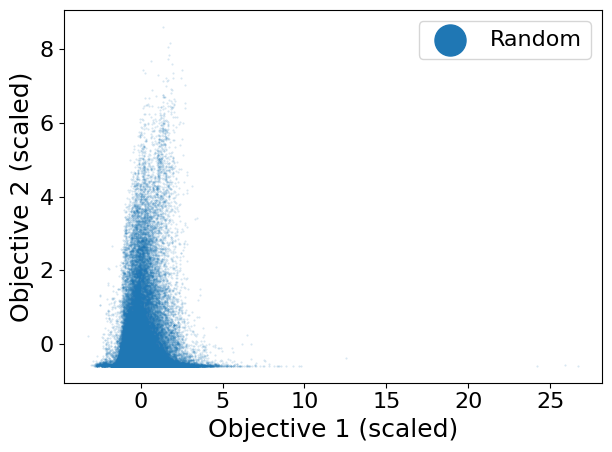

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from blox2.utils import make_scaled_trajectory

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})

n_obs_0 = 10
# results_root, all_path, n_seeds, n_samples = "results/dft_multi", "../data/zinc_dft/properties.csv", 5, 2000
# results_root, all_path, n_seeds, n_samples = "results/material_multi", "../data/material/properties.csv", 20, 400
results_root, all_path, n_seeds, n_samples = "results/dft_multi", "../data/zinc_dft/properties.csv", 1, 87618

n_seeds = 1

dir_names = [
    "04-10_140208_dft_random_all",
]

legends = None
legends = [
    "Random",
]

def load_trajectories_for_dn(dn: str, all_path: str | None, n_seeds: int, results_root: str = "results") -> list[np.ndarray]:
    """
    Load scaled trajectories for a single experiment directory (dn) across multiple seeds.

    Args:
        dn: Experiment directory name under results_root.
        init_path: Path to initial observed properties CSV.
        all_path: Path to global properties CSV used for scaling. If None, no scaling.
        n_seeds: Number of seed_init_{i} folders to load (0, ..., n_seeds-1).
        results_root: Root directory containing experiment outputs.
    """
    trajectories = []
    for seed in range(n_seeds):
        init_path = Path(results_root) / dn / f"seed_init_{seed}" / "initial_observed_properties.csv"
        obs_path = Path(results_root) / dn / f"seed_init_{seed}" / "observation_history.csv"
        if not obs_path.exists():
            raise FileNotFoundError(f"Missing: {obs_path}")

        t = make_scaled_trajectory(init_path, str(obs_path), all_path)
        trajectories.append(t)
    return trajectories


def mean_and_se(arr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mean = arr.mean(axis=0)
    se = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0]) if arr.shape[0] >= 2 else np.zeros_like(mean)
    return mean, se

def plot_metric_across_seeds(trajs_by_dn: list[list[np.ndarray]], labels: list[str], metric_fn, n_obs_0: int, n_samples: int=None, ax=None, ci: bool=False, ci_scale: float=1.0, return_df: bool=False):
    """
    Plot a metric trajectory averaged across seeds for each dn.

    Args:
        trajs_by_dn: list over dn; each element is list over seeds of trajectory arrays.
        labels: legend labels for each dn.
        metric_fn: function that returns metric trajectory
        n_obs_0: number of initial observations (drop prefix for plotting).
        ax: matplotlib axis.
        ci: whether to show shaded band (mean ± ci_scale * SE).
        ci_scale: scale for SE band.
    """
    if len(trajs_by_dn) != len(labels):
        raise ValueError("trajs_by_dn and labels must have the same length.")

    if ax is None:
        ax = plt.gca()
        
    rows = []

    for runs, label in zip(trajs_by_dn, labels):
        metrics = []
        for t in runs:
            m = metric_fn(t)
            metrics.append(m)

        # Ensure same length across seeds (truncate to min length if needed)
        min_len = min(len(m) for m in metrics)
        if n_samples is not None:
            min_len = min(min_len, n_obs_0 + n_samples + 1)
        metrics = np.stack([m[:min_len] for m in metrics], axis=0)  # (n_seeds, T)

        mean, se = mean_and_se(metrics)
        x = np.arange(min_len - n_obs_0)
        if return_df:
            for i, step in enumerate(x):
                rows.append({
                    "label": label,
                    "step": int(step),
                    "mean": float(mean[n_obs_0 + i]),
                    "se": float(se[n_obs_0 + i]),
                    "n_seeds": metrics.shape[0],
                })
            
        y = mean[n_obs_0:]
        ax.plot(x, y, label=label)

        if ci and metrics.shape[0] >= 2:
            band = ci_scale * se[n_obs_0:]
            ax.fill_between(x, y - band, y + band, alpha=0.2)

    ax.legend()
    if return_df:
        return ax, pd.DataFrame(rows)
    else:
        return ax

trajs_by_dn = []
for dn in dir_names:
    # runs = load_trajectories_for_dn(dn=dn, all_path=None, n_seeds=n_seeds, results_root=results_root)
    runs = load_trajectories_for_dn(dn=dn, all_path=all_path, n_seeds=n_seeds, results_root=results_root)
    trajs_by_dn.append(runs)
    
plt.figure()

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(legends))]

for dn_runs, label, color in zip(trajs_by_dn, legends, colors):
    for t in dn_runs:
        plt.scatter(t[:, 0], t[:, 1], alpha=0.2, s=0.2, color=color)

for label, color in zip(legends, colors):
    plt.scatter([], [], s=20, color=color, label=label)
    
plt.legend(markerscale=5)
plt.xlabel("Objective 1 (scaled)")
plt.ylabel("Objective 2 (scaled)")
plt.tight_layout()

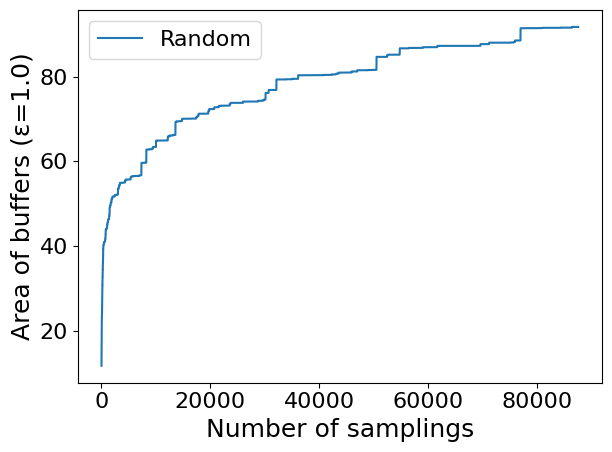

In [9]:
# union of buffers

from blox2 import buffer_union_area_trajectory

radius = 1.0
step = 1

def union_metric(t):
    return buffer_union_area_trajectory(t, radius=radius, step=step)

ax, df = plot_metric_across_seeds(trajs_by_dn=trajs_by_dn, labels=legends, metric_fn=union_metric, n_obs_0=n_obs_0, n_samples=n_samples, ci=True, ci_scale=1.0, return_df=True)
ax.set_xlabel("Number of samplings")
ax.set_ylabel(f"Area of buffers (ε={radius})")
plt.tight_layout()

In [10]:
# save df

name = "dft_example"

file_name = f"results/dft_random_all_eps=1.0" + ".csv"
# file_name = f"results/plots_raw_eps={radius}/{name}" + ".csv"
df.to_csv(file_name, index=False, mode="x")

In [ ]:
# occupancy
from blox2 import make_scaler, occupancy_trajectory

bins = 100
all_props = pd.read_csv(all_path).to_numpy()
scaler = make_scaler(all_props, d=2)
X_all = scaler.transform(all_props)

def occ_metric(t):
    return occupancy_trajectory(t, X_all=X_all, bins=bins)

ax = plot_metric_across_seeds(trajs_by_dn=trajs_by_dn, labels=legends, metric_fn=occ_metric, n_obs_0=n_obs_0, n_samples=n_samples, ci=True, ci_scale=1.0)
ax.set_xlabel("Number of Samplings")
ax.set_ylabel(f"Occupancy (bins: {bins})")
plt.tight_layout()

In [ ]:
# convex hull area
from blox2 import convex_hull_area_trajectory

def ch_metric(t):
    return convex_hull_area_trajectory(t)

ax = plot_metric_across_seeds(trajs_by_dn=trajs_by_dn, labels=legends, metric_fn=ch_metric, n_obs_0=n_obs_0, n_samples=n_samples, ci=True, ci_scale=1.0)
ax.set_xlabel("Number of Samplings")
ax.set_ylabel("Convex hull area")
plt.tight_layout()

In [ ]:
# Stein discrepancy
from blox2 import stein_discrepancy_trajectory

sigma = 1

def sn_metric(t):
    return stein_discrepancy_trajectory(t, sigma=sigma)

ax = plot_metric_across_seeds(trajs_by_dn=trajs_by_dn, labels=legends, metric_fn=sn_metric, n_obs_0=n_obs_0, n_samples=n_samples, ci=True, ci_scale=1.0)
ax.set_xlabel("Number of Samplings")
ax.set_ylabel(f"Stein discrepancy (σ={sigma})")
plt.yscale("log", base=10)
plt.tight_layout()

In [ ]:
# alpha concave area

from blox2 import alpha_concave_hull_area_trajectory

alpha = 0.2

def ac_metric(t):
    return alpha_concave_hull_area_trajectory(t, alpha=alpha)

ax = plot_metric_across_seeds(trajs_by_dn=trajs_by_dn, labels=legends, metric_fn=ac_metric, n_obs_0=n_obs_0, n_samples=n_samples, ci=True, ci_scale=1.0)
ax.set_xlabel("Number of Samplings")
ax.set_ylabel(f"α concave (α={alpha})")
plt.tight_layout()